# 03 · Price elasticity by region — random slopes & endogeneity

**The business decision.** We set prices region by region and want each region's **price elasticity of
demand** — the standard economics measure of how sensitive demand is to price. Concretely, elasticity is
the **% change in quantity sold for a 1% change in price**; it's almost always negative (raise price →
sell less). An elasticity of −1.5 means "cut price 1%, sell 1.5% more." We need it per region because a
tourist market and a price-sensitive suburb should not be priced the same.

### Two traps this notebook is built around

1. **Small regions are noisy.** A region with 12 weeks of data will hand you a wild elasticity estimate
   that's mostly sampling noise. Acting on it is overfitting. The fix is **partial pooling** (below).
2. **Price is endogenous.** "Endogenous" means the treatment (price) is *correlated with the error term*
   — here because managers historically *cut prices when they expected soft demand*. So low prices
   coincide with low demand for reasons that have nothing to do with the price cut, which drags the naive
   elasticity estimate *toward zero* (makes demand look less price-sensitive than it is). No amount of
   clever averaging fixes this — it needs an **instrument** (notebook 11), which we preview at the end.

### The tools, in plain terms

- **Log-log demand.** We model $\log(\text{quantity}) = \alpha + \beta\,\log(\text{price}) + \dots$. The
  magic of taking logs on both sides is that the slope $\beta$ **is** the elasticity directly (a constant
  %-for-% relationship), so there's one interpretable number per region.
- **Random slopes / partial pooling.** Instead of one elasticity for all regions (ignores real
  differences) or a separate free estimate per region (noisy), we assume each region's elasticity
  $\beta_r$ is drawn from a shared distribution $\beta_r \sim \mathcal{N}(\mu_\beta, \tau_\beta)$. This
  **hierarchical** structure makes each region's estimate a compromise between its own noisy data and the
  fleet average — data-poor regions get pulled ("shrunk") harder toward the fleet, which is exactly the
  protection we want. $\mu_\beta$ is the typical elasticity; $\tau_\beta$ measures how much regions
  genuinely differ.

> Cookbook maps this to `pathmc` random slopes; here we fit the equivalent hierarchical model explicitly
> in PyMC so the shrinkage is fully visible. The identification logic is unchanged.

> **On real data.** Swap in your **own transaction panel** — one row per region per week with price,
> units sold, and controls (competitor price, promotions, seasonality). Public analogues are retail
> *scanner* datasets (e.g. the Dominick's Finer Foods store data). The endogeneity caveat is not academic:
> it's the single biggest reason naive "price tests" mislead in practice.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pymc as pm
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=500, tune=500, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 5

## 2 · Simulate a ground truth

A region × week panel with a **constant-elasticity (log-log) demand curve**
$\log Q_{rt}=\alpha_r+\beta_r\log P_{rt}+\gamma^\top Z_{rt}+\varepsilon_{rt}$, where $\beta_r$ is
region $r$'s true price elasticity (planted, varying around a fleet mean ≈ −1.4). Observed
confounders $Z$ = competitor price, seasonality, trend. We start with **no** endogeneity so we
can show recovery, then switch it on in step 7.


In [2]:
df, true_elast = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=SEED)
df["log_price"] = np.log(df["price"]); df["log_demand"] = np.log(df["demand"])
regions = sorted(df["region"].unique()); R = len(regions)
r_idx = df["region"].map({r: i for i, r in enumerate(regions)}).values
# deliberately thin out a few regions so shrinkage has something to do
keep = np.ones(len(df), bool)
for i in [0, 1, 2]:
    ridx = np.where(r_idx == i)[0]
    drop = np.random.default_rng(i).choice(ridx, size=int(len(ridx) * 0.8), replace=False)
    keep[drop] = False
df, r_idx = df[keep].reset_index(drop=True), r_idx[keep]
counts = pd.Series(r_idx).value_counts().sort_index()
print(f"{R} regions, fleet-mean elasticity {true_elast.mean():.2f}; obs per region range {counts.min()}–{counts.max()} "
      f"(regions 0-2 are thin, to exercise shrinkage)")
df.head()

12 regions, fleet-mean elasticity -1.42; obs per region range 16–80 (regions 0-2 are thin, to exercise shrinkage)


,region,week,price,demand,competitor_price,season,trend,log_price,log_demand
0,region_00,2,13.003239,0.159630,20.405765,1.394170e-01,0.02,2.565199,-1.834900
1,region_00,3,14.245949,0.157405,16.535730,1.989368e-01,0.03,2.656473,-1.848934
2,region_00,12,14.310937,0.159097,20.819276,7.179470e-02,0.12,2.661024,-1.838239
3,region_00,13,15.626376,0.175255,21.659711,-9.648736e-17,0.13,2.748960,-1.741513
4,region_00,15,13.204126,0.152195,19.486540,-1.394170e-01,0.15,2.580529,-1.882592


## 3 · Identify — elasticity as a random slope, and the backdoor set

**Estimand.** Per-region elasticity $\beta_r=\partial\log Q/\partial\log P$. **Partial pooling**
treats $\beta_r\sim\mathcal N(\mu_\beta,\tau_\beta^2)$ — noisy regions shrink toward the fleet
mean $\mu_\beta$, and $\tau_\beta$ *measures how much elasticity genuinely varies*. The
**shrinkage factor** for region $r$ is approximately
$\;1-\dfrac{\tau_\beta^2}{\tau_\beta^2+\sigma^2/n_r}\;$ — thin regions (small $n_r$) get pulled
harder toward the fleet. Shrinkage is a feature: it stops us over-reacting to a small region's
noisy slope.

**Confounding is the crux.** Price is endogenous — a demand shock moves both $P$ and $Q$.
Conditioning on the observed backdoor set (competitor price, seasonality, trend) closes the
*observable* paths. What pooling does **not** fix is an *unobserved* common shock — for that you
need an instrument (notebook 11). We state this out loud rather than hide it.


## 4 · Estimate — three pooling regimes, side by side

We fit the same elasticity three ways to make the bias–variance trade-off concrete:
**no pooling** (per-region OLS — unbiased but noisy), **complete pooling** (one fleet elasticity
— stable but ignores real variation), and **partial pooling** (the hierarchical Bayes middle
ground). Only partial pooling gets both the fleet level and the region-to-region spread right.


In [3]:
z = df[["competitor_price", "season", "trend"]].values; z = (z - z.mean(0)) / z.std(0)
lp = df["log_price"].values; ld = df["log_demand"].values

with pm.Model() as model:
    mu_beta = pm.Normal("mu_beta", -1.0, 1.0)
    tau_beta = pm.HalfNormal("tau_beta", 1.0)
    beta_r = pm.Normal("beta_r", mu_beta, tau_beta, shape=R)
    alpha_r = pm.Normal("alpha_r", 0, 5, shape=R)
    gamma = pm.Normal("gamma", 0, 2, shape=z.shape[1])
    sigma = pm.HalfNormal("sigma", 1.0)
    mu = alpha_r[r_idx] + beta_r[r_idx] * lp + z @ gamma
    pm.Normal("obs", mu=mu, sigma=sigma, observed=ld)
    idata = pm.sample(random_seed=SEED, progressbar=False, compute_convergence_checks=False, **FIT)

beta_post = idata.posterior["beta_r"].values.reshape(-1, R)
partial = beta_post.mean(0)
nopool = np.array([np.polyfit(lp[r_idx==i], ld[r_idx==i], 1)[0] for i in range(R)])
complete = np.polyfit(lp, ld, 1)[0]
print(f"fleet-mean elasticity μ_β {idata.posterior['mu_beta'].values.mean():.2f} (true {true_elast.mean():.2f})  ·  "
      f"between-region spread τ_β {idata.posterior['tau_beta'].values.mean():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_beta, tau_beta, beta_r, alpha_r, gamma, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 10 seconds.


fleet-mean elasticity μ_β -1.36 (true -1.42)  ·  between-region spread τ_β 0.31


## 5 · Validate — recovery, shrinkage, and calibration

Estimated vs true elasticity should track the 45° line; the thin regions' point estimates get
pulled toward the fleet mean (that's pooling protecting us), and the credible intervals are
wider where data is thin. We also check that the 90% intervals actually **cover** the true
elasticities (calibration).


MAE — no pool 0.45, complete 0.28, partial 0.21  ·  coverage 67%


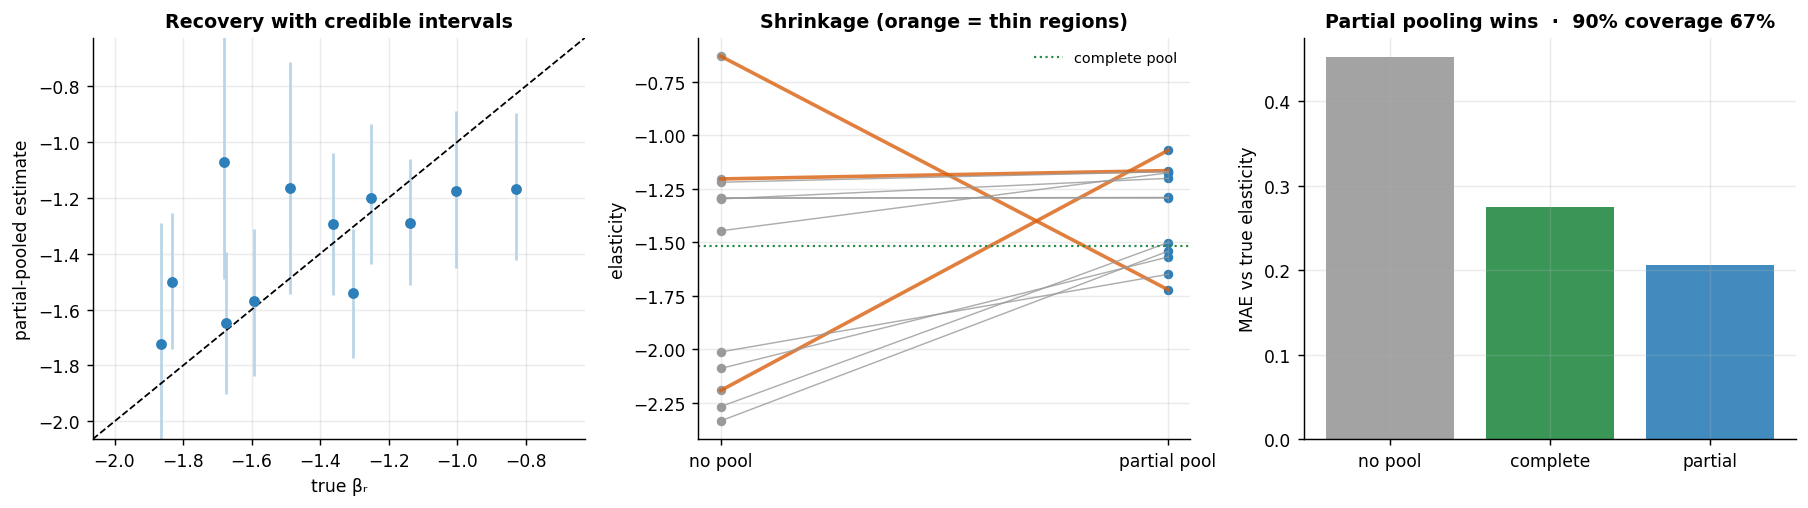

In [4]:
est_lo, est_hi = np.quantile(beta_post, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) recovery with CIs (forest-style vs truth)
ax[0].errorbar(true_elast, partial, yerr=[partial-est_lo, est_hi-partial], fmt="o", color=plots.BLUE, ecolor="#b9d4e8", ms=5)
lim=[min(true_elast.min(),partial.min())-.2, max(true_elast.max(),partial.max())+.2]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("true βᵣ"); ax[0].set_ylabel("partial-pooled estimate"); ax[0].set_title("Recovery with credible intervals")
# (2) shrinkage: no-pool -> partial-pool, thin regions pulled hardest
fleet = partial.mean()
for i in range(R):
    lw = 2.0 if i < 3 else 0.8
    ax[1].plot([0,1],[nopool[i],partial[i]], color=(plots.ORANGE if i<3 else plots.GREY), lw=lw, alpha=0.8)
ax[1].axhline(complete, color=plots.GREEN, ls=":", lw=1.2, label="complete pool")
ax[1].scatter(np.zeros(R), nopool, color=plots.GREY, s=18); ax[1].scatter(np.ones(R), partial, color=plots.BLUE, s=18)
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["no pool","partial pool"]); ax[1].set_ylabel("elasticity")
ax[1].set_title("Shrinkage (orange = thin regions)"); ax[1].legend(frameon=False, fontsize=8)
# (3) calibration + MAE
cover = np.mean((est_lo <= true_elast) & (true_elast <= est_hi))
mae = {"no pool": np.abs(nopool-true_elast).mean(), "complete": np.abs(complete-true_elast).mean(),
       "partial": np.abs(partial-true_elast).mean()}
ax[2].bar(list(mae.keys()), list(mae.values()), color=[plots.GREY, plots.GREEN, plots.BLUE], alpha=0.9)
ax[2].set_ylabel("MAE vs true elasticity"); ax[2].set_title(f"Partial pooling wins  ·  90% coverage {cover:.0%}")
fig.tight_layout()
print(f"MAE — no pool {mae['no pool']:.2f}, complete {mae['complete']:.2f}, partial {mae['partial']:.2f}  ·  coverage {cover:.0%}")

## 6 · Decide, in euros — profit-maximising price per region

For a constant-elasticity demand curve with marginal cost $c$, the profit-maximising price is
$P^\star=\dfrac{\beta}{\beta+1}\,c$ (needs $\beta<-1$). We propagate the **elasticity posterior**
into a **price posterior** per region, and — the honest part — flag regions where we're not
confident demand is even elastic ($\beta<-1$) for a **controlled price test** rather than acting
on a shaky slope.


   region  elasticity  P(elastic) opt_price          action
region_00       -1.07        0.63     €43.4 controlled test
region_01       -1.72        1.00     €19.6       set price
region_02       -1.17        0.75     €38.4 controlled test
region_03       -1.20        0.88     €41.7 controlled test
region_04       -1.18        0.85     €45.5 controlled test
region_05       -1.29        0.97     €34.4       set price
region_06       -1.57        1.00     €22.2       set price
region_07       -1.65        1.00     €20.3       set price
region_08       -1.29        0.98     €35.1       set price
region_09       -1.17        0.85     €47.0 controlled test
region_10       -1.54        1.00     €22.7       set price
region_11       -1.50        1.00     €24.0       set price


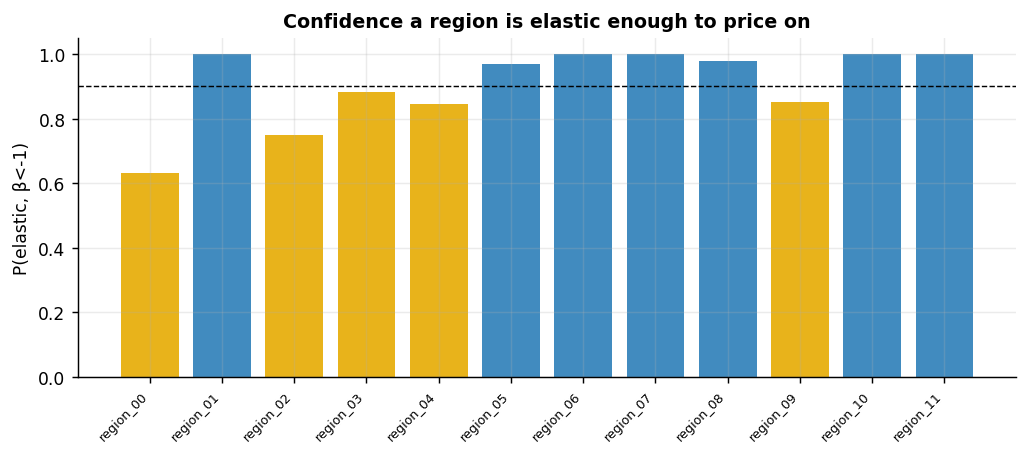

In [5]:
MARGINAL_COST = 8.0
# optimal price posterior per region: P* = beta/(beta+1) * c, valid where beta < -1
def opt_price(beta):
    b = np.where(beta < -1.001, beta, np.nan)
    return b / (b + 1) * MARGINAL_COST
price_post = opt_price(beta_post)                       # (S, R)
p_elastic = (beta_post < -1).mean(0)
rows = []
for i in range(R):
    pp = price_post[:, i]; pp = pp[~np.isnan(pp)]
    conf = p_elastic[i]
    action = "set price" if conf > 0.9 else ("controlled test" if conf > 0.5 else "hold/test")
    rows.append({"region": regions[i], "elasticity": round(partial[i],2), "P(elastic)": round(conf,2),
                 "opt_price": (f"€{np.median(pp):.1f}" if len(pp) else "n/a"), "action": action})
tbl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(range(R), p_elastic, color=[plots.BLUE if c>0.9 else (plots.GOLD if c>0.5 else plots.ORANGE) for c in p_elastic], alpha=0.9)
ax.axhline(0.9, color="k", ls="--", lw=0.8); ax.set_xticks(range(R)); ax.set_xticklabels(regions, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("P(elastic, β<-1)"); ax.set_title("Confidence a region is elastic enough to price on"); fig.tight_layout()
print(tbl.to_string(index=False))

## 7 · Caveats — what partial pooling does *not* fix

Partial pooling handles *noise*, not *bias*. If price is endogenous to an **unobserved** demand
shock, adjusting for observed $Z$ isn't enough and elasticity is biased **toward zero**. We
demonstrate by switching the hidden shock on — and preview the IV cure.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mb, tb, br, ar, g, s]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.


clean fleet elasticity -1.36 (true -1.42)
endogenous fleet elasticity -0.59 (true -1.42) → biased toward zero by +0.83
Fix = an instrument (a cost shifter) or a natural price experiment — see notebook 11 (IV).


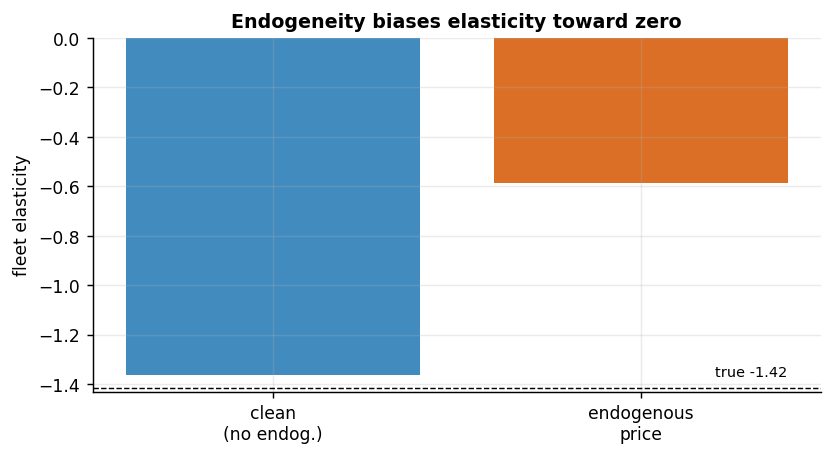

In [6]:
df2, true2 = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=1.2, seed=SEED)
lp2 = np.log(df2["price"].values); ld2 = np.log(df2["demand"].values)
r2 = df2["region"].map({r:i for i,r in enumerate(regions)}).values
z2 = df2[["competitor_price","season","trend"]].values; z2=(z2-z2.mean(0))/z2.std(0)
with pm.Model():
    mb=pm.Normal("mb",-1,1); tb=pm.HalfNormal("tb",1); br=pm.Normal("br",mb,tb,shape=R)
    ar=pm.Normal("ar",0,5,shape=R); g=pm.Normal("g",0,2,shape=3); s=pm.HalfNormal("s",1)
    pm.Normal("o", mu=ar[r2]+br[r2]*lp2+z2@g, sigma=s, observed=ld2)
    id2=pm.sample(draws=300,tune=300,chains=2,random_seed=SEED,progressbar=False,compute_convergence_checks=False)
biased = id2.posterior["br"].values.reshape(-1,R).mean(0)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(["clean\n(no endog.)","endogenous\nprice"], [partial.mean(), biased.mean()], color=[plots.BLUE, plots.ORANGE], alpha=0.9)
ax.axhline(true_elast.mean(), color="k", ls="--", lw=0.8); ax.text(1.4, true_elast.mean()+0.05, f"true {true_elast.mean():.2f}", ha="right", fontsize=8)
ax.set_ylabel("fleet elasticity"); ax.set_title("Endogeneity biases elasticity toward zero"); fig.tight_layout()
print(f"clean fleet elasticity {partial.mean():.2f} (true {true_elast.mean():.2f})")
print(f"endogenous fleet elasticity {biased.mean():.2f} (true {true2.mean():.2f}) → biased toward zero by {biased.mean()-true2.mean():+.2f}")
print("Fix = an instrument (a cost shifter) or a natural price experiment — see notebook 11 (IV).")

**Other caveats.** Log-log assumes *constant* elasticity within region (a local approximation
if elasticity varies with price level); `lag(price)` would capture stockpiling dynamics (omitted
for clarity); and shrinkage is a prior choice — too few regions or a mis-specified $\tau_\beta$
prior can over-pool, so always inspect the fleet-vs-region spread.
